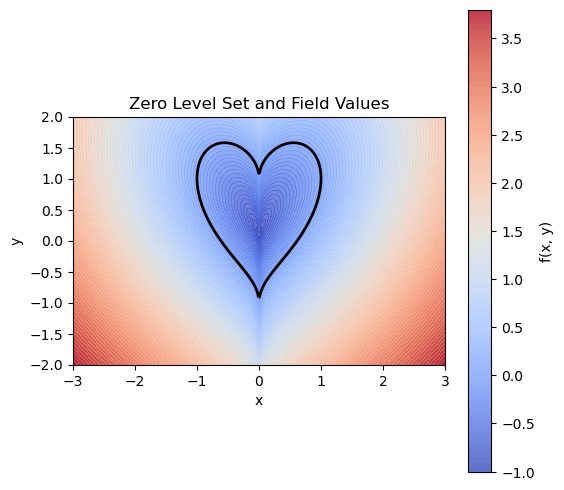

In [5]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# Define your signed distance function (SDF) or scalar field here
def f(x, y):
    # Example: circle centered at (0, 0) with radius 1
    return np.sqrt(x**2 + y**2) - 1

    
def f(x, y):
    b = np.array([1.0, 0.5])  # half-size (width=2, height=1)
    qx, qy = np.abs(x) - b[0], np.abs(y) - b[1]
    return np.sqrt(np.maximum(qx, 0)**2 + np.maximum(qy, 0)**2) + np.minimum(np.maximum(qx, qy), 0)
def f(x, y):
    r1, r2 = 1.0, 0.2
    q = np.sqrt(x**2 + y**2) - r1
    return np.abs(q) - r2


def f(x, y):
    r = np.sqrt(x**2 + y**2)
    a = np.arctan2(y, x)
    n = 5  # number of points
    k = np.cos(np.floor(0.5 + n * a) * (2*np.pi / n))
    return r - 0.5 - 0.2 * k


def f(x, y):
    x *= 1.5
    a = x**2 + (y - np.sqrt(np.abs(x)))**2
    return np.sqrt(a) - 1.0


# %%
# Plotting utility
def plot_levelset(f, xlim=(-2, 2), ylim=(-2, 2), resolution=400):
    x = np.linspace(*xlim, resolution)
    y = np.linspace(*ylim, resolution)
    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)

    fig, ax = plt.subplots(figsize=(6, 6))
    # Color map showing signed values
    c = ax.contourf(X, Y, Z, levels=100, cmap='coolwarm', alpha=0.8)
    # Zero level set (boundary)
    cs = ax.contour(X, Y, Z, levels=[0], colors='black', linewidths=2)

    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Zero Level Set and Field Values')
    fig.colorbar(c, ax=ax, label='f(x, y)')
    plt.show()

# %%
# Run this cell to visualize your current f
plot_levelset(f)


In [7]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown, fixed

# --- Define some interesting SDFs ---

def sdf_circle(x, y, r=1.0):
    return np.sqrt(x**2 + y**2) - r

def sdf_box(x, y, w=1.0, h=0.5):
    qx, qy = np.abs(x) - w, np.abs(y) - h
    return np.sqrt(np.maximum(qx, 0)**2 + np.maximum(qy, 0)**2) + np.minimum(np.maximum(qx, qy), 0)

def sdf_rounded_box(x, y, w=1.0, h=0.6, r=0.2):
    qx, qy = np.abs(x) - w + r, np.abs(y) - h + r
    return np.sqrt(np.maximum(qx, 0)**2 + np.maximum(qy, 0)**2) - r

def sdf_ring(x, y, r1=1.0, r2=0.2):
    q = np.sqrt(x**2 + y**2) - r1
    return np.abs(q) - r2

def sdf_moon(x, y, r1=1.0, r2=0.8, offset=0.5):
    a = np.sqrt(x**2 + y**2) - r1
    b = np.sqrt((x + offset)**2 + y**2) - r2
    return np.maximum(-a, b)

def sdf_star(x, y, r=1.0, n=5, dent=0.3):
    a = np.arctan2(y, x)
    rr = np.sqrt(x**2 + y**2)
    k = np.cos(np.floor(0.5 + n * a / np.pi) * np.pi / n)
    return rr - r * (1 - dent * k)

def sdf_wavy_circle(x, y, r=1.0, freq=6.0, amp=0.2):
    return np.sqrt(x**2 + y**2) - r + amp * np.sin(freq * np.sqrt(x**2 + y**2))

# --- Plotter ---
def plot_sdf(sdf_func, xlim=(-2, 2), ylim=(-2, 2), resolution=400, **kwargs):
    x = np.linspace(*xlim, resolution)
    y = np.linspace(*ylim, resolution)
    X, Y = np.meshgrid(x, y)
    Z = sdf_func(X, Y, **kwargs)

    fig, ax = plt.subplots(figsize=(6, 6))
    c = ax.contourf(X, Y, Z, levels=100, cmap='coolwarm', alpha=0.85)
    ax.contour(X, Y, Z, levels=[0], colors='black', linewidths=2)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{sdf_func.__name__}  —  zero level set')
    fig.colorbar(c, ax=ax, label='f(x, y)')
    plt.show()

# --- Interactive UI ---
def interactive_sdf(shape):
    if shape == 'Circle':
        interact(lambda r: plot_sdf(sdf_circle, r=r),
                 r=FloatSlider(1.0, 0.1, 2.0, step=0.05))
    elif shape == 'Box':
        interact(lambda w, h: plot_sdf(sdf_box, w=w, h=h),
                 w=FloatSlider(1.0, 0.1, 2.0, step=0.05),
                 h=FloatSlider(0.5, 0.1, 2.0, step=0.05))
    elif shape == 'Rounded Box':
        interact(lambda w, h, r: plot_sdf(sdf_rounded_box, w=w, h=h, r=r),
                 w=FloatSlider(1.0, 0.1, 2.0, step=0.05),
                 h=FloatSlider(0.6, 0.1, 2.0, step=0.05),
                 r=FloatSlider(0.2, 0.0, 0.5, step=0.05))
    elif shape == 'Ring':
        interact(lambda r1, r2: plot_sdf(sdf_ring, r1=r1, r2=r2),
                 r1=FloatSlider(1.0, 0.1, 2.0, step=0.05),
                 r2=FloatSlider(0.2, 0.05, 1.0, step=0.05))
    elif shape == 'Moon':
        interact(lambda r1, r2, offset: plot_sdf(sdf_moon, r1=r1, r2=r2, offset=offset),
                 r1=FloatSlider(1.0, 0.1, 2.0, step=0.05),
                 r2=FloatSlider(0.8, 0.1, 2.0, step=0.05),
                 offset=FloatSlider(0.5, 0.0, 1.0, step=0.05))
    elif shape == 'Star':
        interact(lambda r, n, dent: plot_sdf(sdf_star, r=r, n=n, dent=dent),
                 r=FloatSlider(1.0, 0.1, 2.0, step=0.05),
                 n=FloatSlider(3, 3, 12, step=1),
                 dent=FloatSlider(0.3, 0.0, 0.9, step=0.05))
    elif shape == 'Wavy Circle':
        interact(lambda r, freq, amp: plot_sdf(sdf_wavy_circle, r=r, freq=freq, amp=amp),
                 r=FloatSlider(1.0, 0.1, 2.0, step=0.05),
                 freq=FloatSlider(6.0, 1.0, 12.0, step=0.5),
                 amp=FloatSlider(0.2, 0.0, 0.5, step=0.05))

# --- Master dropdown ---
interact(interactive_sdf,
         shape=Dropdown(
             options=['Circle', 'Box', 'Rounded Box', 'Ring', 'Moon', 'Star', 'Wavy Circle'],
             value='Circle',
             description='SDF Shape:'
         ));


interactive(children=(Dropdown(description='SDF Shape:', options=('Circle', 'Box', 'Rounded Box', 'Ring', 'Moo…

In [9]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown

# --- Define SDFs ---
def sdf_circle(x, y, r=1.0):
    return np.sqrt(x**2 + y**2) - r

def sdf_box(x, y, w=1.0, h=0.5):
    qx, qy = np.abs(x) - w, np.abs(y) - h
    return np.sqrt(np.maximum(qx, 0)**2 + np.maximum(qy, 0)**2) + np.minimum(np.maximum(qx, qy), 0)

def sdf_rounded_box(x, y, w=1.0, h=0.6, r=0.2):
    qx, qy = np.abs(x) - w + r, np.abs(y) - h + r
    return np.sqrt(np.maximum(qx, 0)**2 + np.maximum(qy, 0)**2) - r

def sdf_ring(x, y, r1=1.0, r2=0.2):
    q = np.sqrt(x**2 + y**2) - r1
    return np.abs(q) - r2

def sdf_moon(x, y, r1=1.0, r2=0.8, offset=0.5):
    a = np.sqrt(x**2 + y**2) - r1
    b = np.sqrt((x + offset)**2 + y**2) - r2
    return np.maximum(-a, b)

def sdf_star(x, y, r=1.0, n=5, dent=0.3):
    a = np.arctan2(y, x)
    rr = np.sqrt(x**2 + y**2)
    k = np.cos(np.floor(0.5 + n * a / np.pi) * np.pi / n)
    return rr - r * (1 - dent * k)

def sdf_wavy_circle(x, y, r=1.0, freq=6.0, amp=0.2):
    return np.sqrt(x**2 + y**2) - r + amp * np.sin(freq * np.sqrt(x**2 + y**2))

# --- Plot function (zero-centered diverging colormap) ---
def plot_sdf(sdf_func, xlim=(-2, 2), ylim=(-2, 2), resolution=400, **kwargs):
    x = np.linspace(*xlim, resolution)
    y = np.linspace(*ylim, resolution)
    X, Y = np.meshgrid(x, y)
    Z = sdf_func(X, Y, **kwargs)

    # Determine symmetric color limits
    max_abs = np.max(np.abs(Z))
    vmin, vmax = -max_abs, max_abs

    fig, ax = plt.subplots(figsize=(6, 6))
    c = ax.contourf(X, Y, Z, levels=200, cmap='coolwarm', vmin=vmin, vmax=vmax)
    ax.contour(X, Y, Z, levels=[0], colors='black', linewidths=2)

    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{sdf_func.__name__} — zero-centered colormap')

    cb = fig.colorbar(c, ax=ax, label='f(x, y)')
    cb.set_ticks([vmin, 0, vmax])
    cb.ax.set_yticklabels([f'{vmin:.2f}', '0', f'{vmax:.2f}'])

    plt.show()

# --- Interactive controls ---
def interactive_sdf(shape):
    if shape == 'Circle':
        interact(lambda r: plot_sdf(sdf_circle, r=r),
                 r=FloatSlider(value=1.0, min=0.1, max=2.0, step=0.05))
    elif shape == 'Box':
        interact(lambda w, h: plot_sdf(sdf_box, w=w, h=h),
                 w=FloatSlider(value=1.0, min=0.1, max=2.0, step=0.05),
                 h=FloatSlider(value=0.5, min=0.1, max=2.0, step=0.05))
    elif shape == 'Rounded Box':
        interact(lambda w, h, r: plot_sdf(sdf_rounded_box, w=w, h=h, r=r),
                 w=FloatSlider(value=1.0, min=0.1, max=2.0, step=0.05),
                 h=FloatSlider(value=0.6, min=0.1, max=2.0, step=0.05),
                 r=FloatSlider(value=0.2, min=0.0, max=0.5, step=0.05))
    elif shape == 'Ring':
        interact(lambda r1, r2: plot_sdf(sdf_ring, r1=r1, r2=r2),
                 r1=FloatSlider(value=1.0, min=0.1, max=2.0, step=0.05),
                 r2=FloatSlider(value=0.2, min=0.05, max=1.0, step=0.05))
    elif shape == 'Moon':
        interact(lambda r1, r2, offset: plot_sdf(sdf_moon, r1=r1, r2=r2, offset=offset),
                 r1=FloatSlider(value=1.0, min=0.1, max=2.0, step=0.05),
                 r2=FloatSlider(value=0.8, min=0.1, max=2.0, step=0.05),
                 offset=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.05))
    elif shape == 'Star':
        interact(lambda r, n, dent: plot_sdf(sdf_star, r=r, n=n, dent=dent),
                 r=FloatSlider(value=1.0, min=0.1, max=2.0, step=0.05),
                 n=FloatSlider(value=5, min=3, max=12, step=1),
                 dent=FloatSlider(value=0.3, min=0.0, max=0.9, step=0.05))
    elif shape == 'Wavy Circle':
        interact(lambda r, freq, amp: plot_sdf(sdf_wavy_circle, r=r, freq=freq, amp=amp),
                 r=FloatSlider(value=1.0, min=0.1, max=2.0, step=0.05),
                 freq=FloatSlider(value=6.0, min=1.0, max=12.0, step=0.5),
                 amp=FloatSlider(value=0.2, min=0.0, max=0.5, step=0.05))

# --- Main dropdown ---
interact(interactive_sdf,
         shape=Dropdown(
             options=['Circle', 'Box', 'Rounded Box', 'Ring', 'Moon', 'Star', 'Wavy Circle'],
             value='Circle',
             description='SDF Shape:'
         ));


interactive(children=(Dropdown(description='SDF Shape:', options=('Circle', 'Box', 'Rounded Box', 'Ring', 'Moo…